In [1]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

i) y' = -x y → Eq(y(x), C1*exp(-x**2/2))
ii) y' = x y → Eq(y(x), C1*exp(x**2/2))
iii) x dx + y dy = 0 → Eq(y(x), -sqrt(C1 - x**2))
iv) y dx + x dy = 0 → Eq(y(x), C1/x)
v) dy/dx = y^2 - y → Eq(y(x), C1/(C1 - exp(x)))
x and y must have same first dimension, but have shapes (200,) and (1,)
x and y must have same first dimension, but have shapes (200,) and (1,)


<lambdifygenerated-58>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(4 - x**2)
<lambdifygenerated-59>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(1 - x**2)
<lambdifygenerated-60>:2: RuntimeWarning: invalid value encountered in sqrt
  return -sqrt(-x**2)
<lambdifygenerated-61>:2: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(1 - x**2)
<lambdifygenerated-62>:2: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(4 - x**2)
/tmp/ipython-input-1561768017.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


x and y must have same first dimension, but have shapes (200,) and (1,)
x and y must have same first dimension, but have shapes (200,) and (1,)
x and y must have same first dimension, but have shapes (200,) and (1,)
x and y must have same first dimension, but have shapes (200,) and (1,)
x and y must have same first dimension, but have shapes (200,) and (1,)
x and y must have same first dimension, but have shapes (200,) and (1,)
Couldn't solve for initial conditions


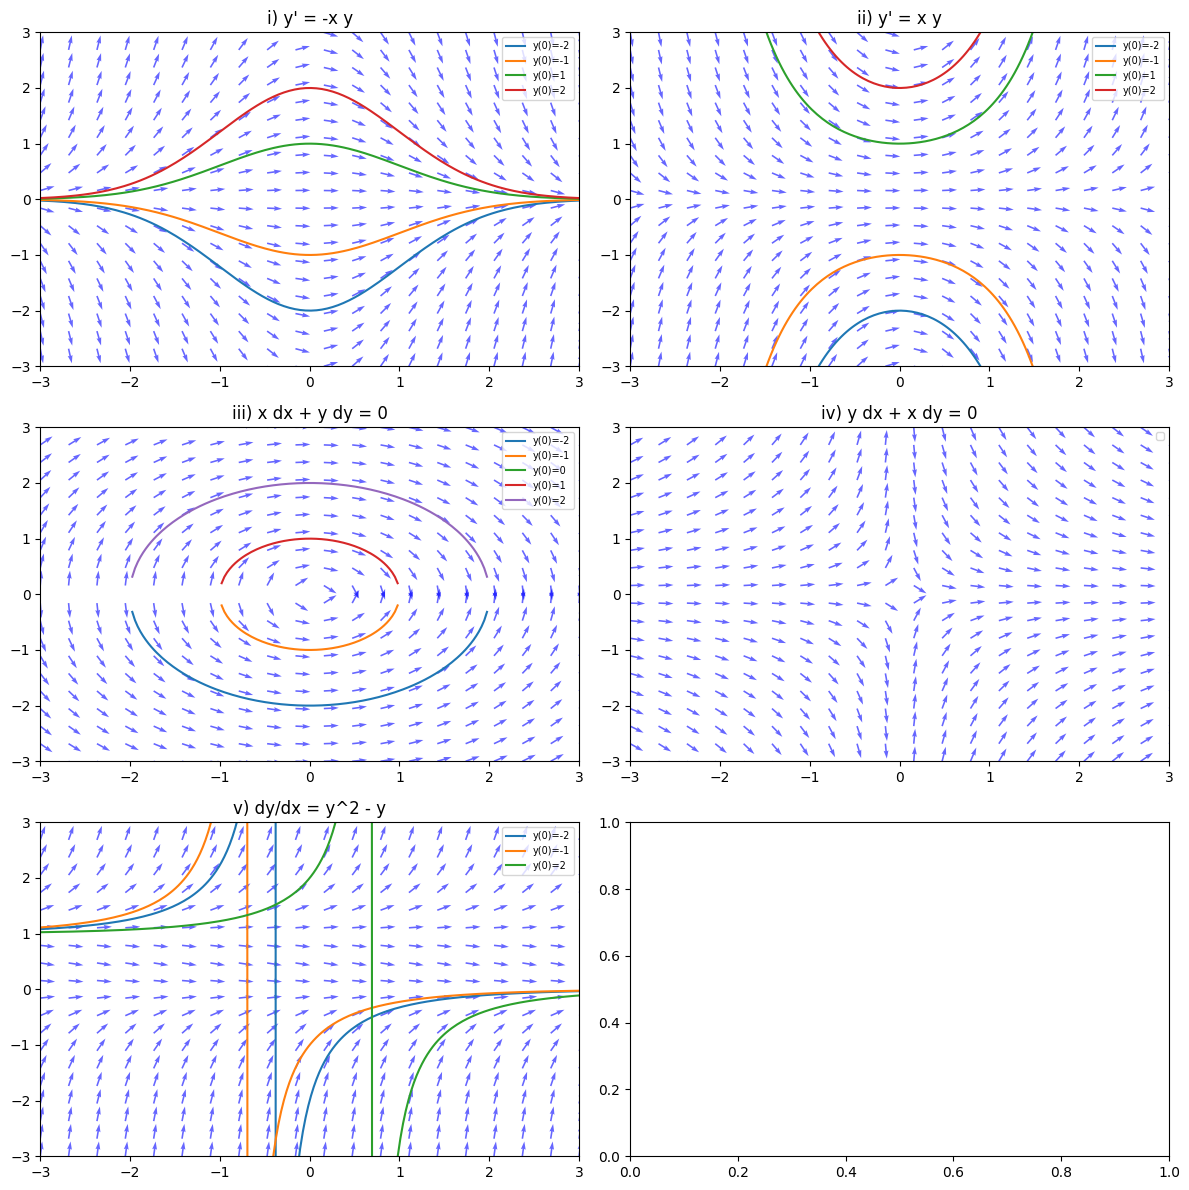

In [5]:

x = sp.Symbol('x')
y = sp.Function('y')

edos = {
    "i) y' = -x y": sp.Eq(sp.diff(y(x), x), -x*y(x)),
    "ii) y' = x y": sp.Eq(sp.diff(y(x), x), x*y(x)),
    "iii) x dx + y dy = 0": sp.Eq(sp.diff(y(x), x), -x/y(x)),
    "iv) y dx + x dy = 0": sp.Eq(sp.diff(y(x), x), -y(x)/x),
    "v) dy/dx = y^2 - y": sp.Eq(sp.diff(y(x), x), y(x)**2 - y(x))
}

solutions = {}
for name, eq in edos.items():
    sol = sp.dsolve(eq)
    if isinstance(sol, list):
        sol = sol[0]
    solutions[name] = sol

for k, v in solutions.items():
    print(f"{k} → {v}")

x_vals = np.linspace(-3, 3, 20)
y_vals = np.linspace(-3, 3, 20)
X, Y = np.meshgrid(x_vals, y_vals)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.ravel()

for i, (name, eq) in enumerate(edos.items()):
    rhs = sp.solve(eq, sp.Derivative(y(x), x))[0]
    f = sp.lambdify((x, y(x)), rhs, "numpy")

    U = np.ones_like(X)
    V = f(X, Y)
    N = np.sqrt(U**2 + V**2)
    U, V = U/N, V/N

    ax = axes[i]
    ax.quiver(X, Y, U, V, angles="xy", color="blue", alpha=0.6)

    for y0 in [-2, -1, 0, 1, 2]:
        try:
            sol_num = sp.dsolve(eq, ics={y(0): y0})
            if isinstance(sol_num, list):
                sol_num = sol_num[0]
            if isinstance(sol_num, sp.Eq):
                y_func = sp.lambdify(x, sol_num.rhs, "numpy")
                xx = np.linspace(-3, 3, 200)
                ax.plot(xx, y_func(xx), label=f"y(0)={y0}")
        except Exception as e:
            print(f"{e}")

    ax.set_title(name)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()



## i) y' = -x y
Al observar el campo de pendientes se nota que en x = 0 todas las rectas se hacen horizontales y conforme uno se aleja en x la pendiente cambia de signo. La solución analítica es y(x) = C e^(-x²/2), que describe curvas en forma de campana que tienden a cero cuando |x| crece. Las gráficas coinciden con lo esperado pues se aplanan en el eje vertical y se extinguen hacia los lados.

## ii) y' = x y
El campo de pendientes muestra que para x positivo las soluciones crecen rápido y para x negativo decrecen si son positivas. La solución general es y(x) = C e^(x²/2), que crece de manera rápida al alejarse del origen. Las curvas dibujadas siguen exactamente este comportamiento, confirmando la intuición del esbozo.

## iii) x dx + y dy = 0
El campo muestra trayectorias cerradas alrededor del origen. La solución implícita es x² + y² = C, es decir circunferencias. El esbozo esperado coincide: las curvas solución son círculos concéntricos, aunque en la forma y' = -x/y se ve un hueco en y = 0 porque allí la pendiente no está definida.

## iv) y dx + x dy = 0
Aquí el campo apunta hacia hipérbolas con asíntotas en los ejes. La solución implícita es xy = C, que describe familias de hipérbolas y como casos particulares las rectas coordenadas. En la gráfica no aparecieron todas las curvas porque se intentaron condiciones iniciales en x = 0, donde la ecuación no está definida. Si se eligen puntos iniciales fuera del eje vertical, se recuperan las hipérbolas sin problema.

## v) y' = y² - y
El campo muestra claramente que y = 0 y y = 1 son rectas horizontales de equilibrio. La solución analítica es y(x) = C / (C - e^x), que produce asíntotas verticales y tiene exactamente esos equilibrios. En la gráfica se ven esas líneas de equilibrio y las curvas que se acercan o alejan de ellas según el valor inicial, lo que coincide con lo previsto cualitativamente.
